# Part 2.3 — Birthday Cake Sketches with a DCGAN (QuickDraw)

Training a **DCGAN** to generate birthday-cake doodles from Google's QuickDraw dataset, then comparing to real sketches with **FID**. The extension trains the same model on other categories (cat, house) to see how sketch complexity affects results.



## 1. Setup

In [ ]:
import numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Download and explore 'birthday cake'

QuickDraw provides each category as a `.npy` bitmap file — an array of 28×28 grayscale sketches. Downloading the birthday-cake set and looking at a few.

Sketches: 144982 | each is 28x28 = 784


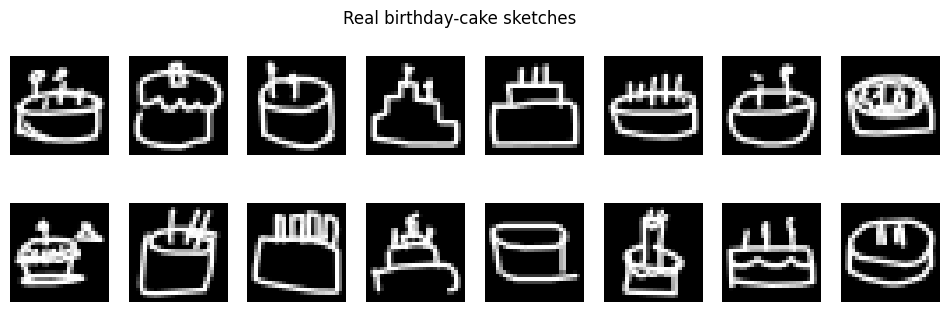

In [ ]:
!wget -q -O birthday_cake.npy "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday%20cake.npy"
data = np.load("birthday_cake.npy")           # (N, 784) uint8
print("Sketches:", data.shape[0], "| each is 28x28 =", data.shape[1])

fig, ax = plt.subplots(2, 8, figsize=(12, 3.5))
for a in ax.flat:
    a.imshow(data[np.random.randint(len(data))].reshape(28,28), cmap="gray")
    a.axis("off")
plt.suptitle("Real birthday-cake sketches"); plt.show()

## 3. Prepare the data

A reusable helper: take a QuickDraw array, subsample for speed, resize 28→32 (clean powers of two), and scale to `[-1, 1]` for the `Tanh` output.

In [ ]:
def make_loader(arr, n=30000, batch_size=128):
    idx = np.random.RandomState(42).choice(len(arr), min(n, len(arr)), replace=False)
    imgs = torch.tensor(arr[idx].reshape(-1,1,28,28)).float()
    imgs = F.interpolate(imgs, size=32, mode="bilinear", align_corners=False)
    imgs = imgs / 127.5 - 1.0                 # -> [-1, 1]
    return DataLoader(TensorDataset(imgs), batch_size=batch_size, shuffle=True, drop_last=True)

loader = make_loader(data)
print("Batches per epoch:", len(loader))

Batches per epoch: 234


## 4. DCGAN models

Same architecture as the OCT DCGAN: transposed-conv generator (→32×32, `Tanh`) and conv discriminator (→real/fake, `Sigmoid`), plus the recommended weight init.

In [ ]:
nz, ngf, ndf = 100, 64, 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 1, 4, 2, 1, bias=False), nn.Tanh(),
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False), nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x).view(-1, 1)

def weights_init(m):
    cn = m.__class__.__name__
    if "Conv" in cn: nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02); nn.init.constant_(m.bias.data, 0)

## 5. Train

A reusable training function (so the extension can call it too). As well as the loss history, it displays a grid of generated samples every few epochs using a fixed noise vector, so the **visual output is tracked across epochs**, not just the losses.

In [ ]:
def train_dcgan(loader, num_epochs=30, snapshot_every=10):
    G = Generator().to(device); G.apply(weights_init)
    D = Discriminator().to(device); D.apply(weights_init)
    criterion = nn.BCELoss()
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
    fixed = torch.randn(16, nz, 1, 1, device=device)   # same noise each snapshot to watch progress
    G_losses, D_losses = [], []
    for epoch in range(num_epochs):
        for (real,) in loader:
            real = real.to(device); bs = real.size(0)
            D.zero_grad()
            loss_real = criterion(D(real), torch.ones(bs,1,device=device))
            z = torch.randn(bs, nz, 1, 1, device=device); fake = G(z)
            loss_fake = criterion(D(fake.detach()), torch.zeros(bs,1,device=device))
            loss_D = loss_real + loss_fake
            loss_D.backward(); opt_D.step()
            G.zero_grad()
            loss_G = criterion(D(fake), torch.ones(bs,1,device=device))
            loss_G.backward(); opt_G.step()
        G_losses.append(loss_G.item()); D_losses.append(loss_D.item())
        print(f"Epoch {epoch+1:2d}/{num_epochs} | D {loss_D.item():.3f} | G {loss_G.item():.3f}")
        if epoch == 0 or (epoch+1) % snapshot_every == 0:
            G.eval()
            with torch.no_grad():
                snap = G(fixed).cpu()
            G.train()
            grid = vutils.make_grid(snap, nrow=8, normalize=True)
            plt.figure(figsize=(8,2))
            plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray"); plt.axis("off")
            plt.title(f"Generated samples at epoch {epoch+1}"); plt.show()
    return G, G_losses, D_losses

G, G_losses, D_losses = train_dcgan(loader)

Epoch  1/30 | D 0.097 | G 5.347
Epoch  2/30 | D 0.101 | G 4.237
Epoch  3/30 | D 0.237 | G 3.539
Epoch  4/30 | D 1.817 | G 0.836
Epoch  5/30 | D 0.270 | G 2.781
Epoch  6/30 | D 0.100 | G 3.198
Epoch  7/30 | D 0.083 | G 3.914
Epoch  8/30 | D 0.086 | G 3.750
Epoch  9/30 | D 0.092 | G 3.943
Epoch 10/30 | D 0.059 | G 4.121
Epoch 11/30 | D 0.349 | G 3.766
Epoch 12/30 | D 0.040 | G 4.608
Epoch 13/30 | D 0.183 | G 3.092
Epoch 14/30 | D 0.035 | G 4.553
Epoch 15/30 | D 0.059 | G 4.756
Epoch 16/30 | D 0.047 | G 5.162
Epoch 17/30 | D 0.095 | G 3.853
Epoch 18/30 | D 0.026 | G 4.886
Epoch 19/30 | D 0.592 | G 5.893
Epoch 20/30 | D 0.699 | G 1.842
Epoch 21/30 | D 0.041 | G 4.514
Epoch 22/30 | D 0.026 | G 4.990
Epoch 23/30 | D 1.331 | G 1.834
Epoch 24/30 | D 0.356 | G 1.892
Epoch 25/30 | D 0.020 | G 5.320
Epoch 26/30 | D 2.218 | G 0.382
Epoch 27/30 | D 0.022 | G 5.243
Epoch 28/30 | D 0.023 | G 5.933
Epoch 29/30 | D 0.017 | G 5.506
Epoch 30/30 | D 0.644 | G 1.845


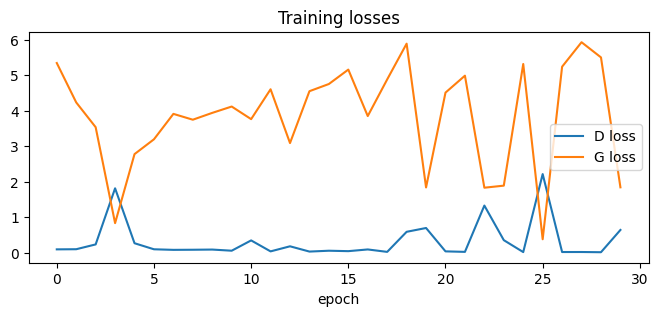

In [ ]:
plt.figure(figsize=(8,3))
plt.plot(D_losses, label="D loss"); plt.plot(G_losses, label="G loss")
plt.xlabel("epoch"); plt.legend(); plt.title("Training losses"); plt.show()

## 6. Generate fake sketches

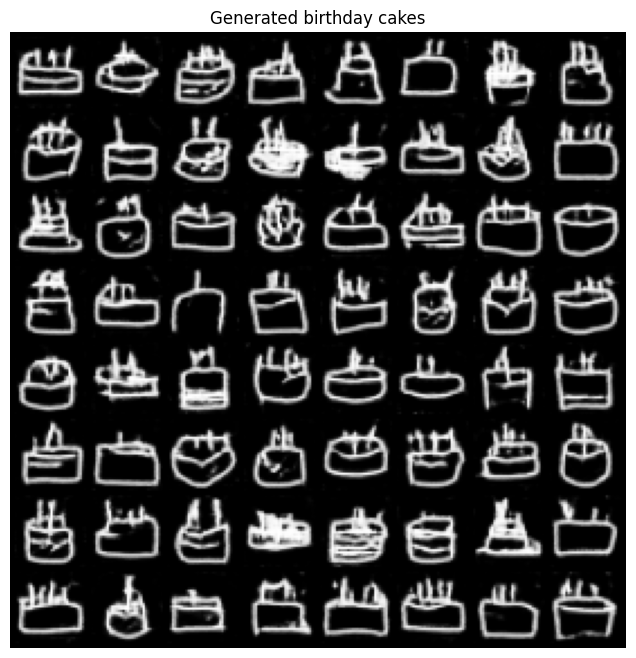

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

In [ ]:
G.eval()
with torch.no_grad():
    fake = G(torch.randn(64, nz, 1, 1, device=device)).cpu()
grid = vutils.make_grid(fake, nrow=8, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray"); plt.axis("off")
plt.title("Generated birthday cakes"); plt.show()
G.train()

## 7. Evaluate with FID

Standalone FID using InceptionV3 features (lower is better).

In [ ]:
from torchvision.models import inception_v3
from scipy import linalg

incep = inception_v3(weights="DEFAULT", transform_input=False).to(device)
incep.fc = torch.nn.Identity(); incep.eval()
_mean = torch.tensor([0.485,0.456,0.406], device=device).view(1,3,1,1)
_std  = torch.tensor([0.229,0.224,0.225], device=device).view(1,3,1,1)

def get_features(imgs):
    feats = []
    with torch.no_grad():
        for i in range(0, imgs.size(0), 100):
            x = (imgs[i:i+100] + 1) / 2
            x = x.repeat(1,3,1,1)
            x = F.interpolate(x, size=(299,299), mode="bilinear", align_corners=False)
            x = (x - _mean) / _std
            feats.append(incep(x).cpu().numpy())
    return np.concatenate(feats, 0)

def fid_score(real_imgs, fake_imgs):
    fr, ff = get_features(real_imgs), get_features(fake_imgs)
    mu1, s1 = fr.mean(0), np.cov(fr, rowvar=False)
    mu2, s2 = ff.mean(0), np.cov(ff, rowvar=False)
    diff = mu1 - mu2
    cov = linalg.sqrtm(s1.dot(s2))
    if np.iscomplexobj(cov): cov = cov.real
    return float(diff.dot(diff) + np.trace(s1 + s2 - 2*cov))

# real batch straight from the loader's tensors
real_eval = loader.dataset.tensors[0][:2000].to(device)
G.eval()
with torch.no_grad():
    fake_eval = torch.cat([G(torch.randn(200, nz,1,1, device=device)) for _ in range(10)])
G.train()
print("FID:", fid_score(real_eval, fake_eval))

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 183MB/s] 


FID: 35.35044134759155


### Real vs fake side by side

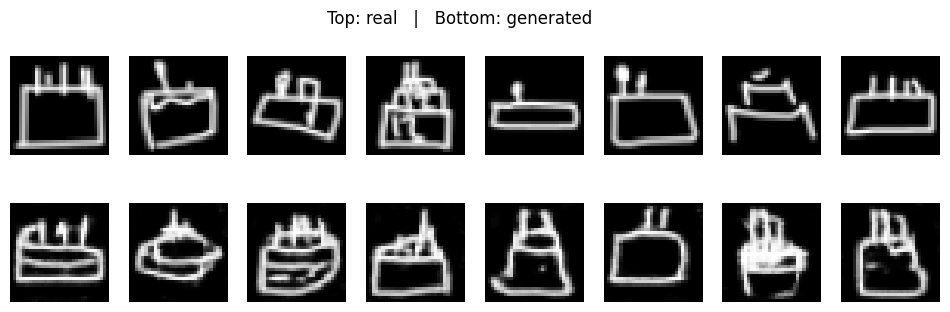

In [ ]:
fig, ax = plt.subplots(2, 8, figsize=(12, 3.5))
for k in range(8):
    ax[0,k].imshow(real_eval[k].cpu().squeeze()*0.5+0.5, cmap="gray"); ax[0,k].axis("off")
    ax[1,k].imshow(fake[k].squeeze()*0.5+0.5, cmap="gray"); ax[1,k].axis("off")
plt.suptitle("Top: real   |   Bottom: generated"); plt.show()

## 8. Reflection
Training the DCGAN on the Birthday Cake category demonstrated how a GAN can learn the overall structure of simple sketch images from random noise. The generated sketches captured the main characteristics of birthday cakes, including the layered shape and candles, making most of the images recognisable. However, some sketches were less detailed than the original QuickDraw drawings, with rough edges and slightly distorted shapes. This is expected because the generator learns the data distribution gradually through adversarial training.

The model achieved an FID score of 35.35. Since lower FID values indicate that the generated images are closer to the real data distribution, this result suggests that the generator learned the Birthday Cake sketches reasonably well. Although the generated images are not identical to the real sketches, they preserve the overall appearance and structure, indicating that the model successfully captured the main features of the dataset.

Overall, this experiment showed that a DCGAN can generate realistic sketch images after sufficient training. While some generated samples still lacked fine details and variation, the results demonstrate that the model learned the underlying distribution of the QuickDraw dataset and produced recognisable synthetic images.

## 9. Extension — other categories

Reusing the exact same pipeline on other QuickDraw categories to compare how the model handles different sketch complexity. Cats and houses are more structurally varied than cakes.

Epoch  1/30 | D 0.226 | G 4.054
Epoch  2/30 | D 0.156 | G 2.004
Epoch  3/30 | D 0.118 | G 3.055
Epoch  4/30 | D 0.338 | G 2.467
Epoch  5/30 | D 0.604 | G 2.984
Epoch  6/30 | D 0.206 | G 2.609
Epoch  7/30 | D 0.166 | G 2.603
Epoch  8/30 | D 0.118 | G 3.447
Epoch  9/30 | D 0.769 | G 6.929
Epoch 10/30 | D 0.390 | G 2.247
Epoch 11/30 | D 0.067 | G 3.464
Epoch 12/30 | D 0.062 | G 4.497
Epoch 13/30 | D 0.403 | G 2.577
Epoch 14/30 | D 0.028 | G 5.282
Epoch 15/30 | D 0.554 | G 2.159
Epoch 16/30 | D 0.098 | G 4.151
Epoch 17/30 | D 0.060 | G 6.065
Epoch 18/30 | D 0.055 | G 4.414
Epoch 19/30 | D 0.018 | G 5.023
Epoch 20/30 | D 0.015 | G 5.423
Epoch 21/30 | D 0.178 | G 2.701
Epoch 22/30 | D 0.042 | G 3.822
Epoch 23/30 | D 0.017 | G 5.712
Epoch 24/30 | D 0.854 | G 1.377
Epoch 25/30 | D 0.469 | G 2.492
Epoch 26/30 | D 0.575 | G 2.304
Epoch 27/30 | D 0.089 | G 3.632
Epoch 28/30 | D 0.026 | G 5.100
Epoch 29/30 | D 0.020 | G 5.579
Epoch 30/30 | D 0.613 | G 2.341


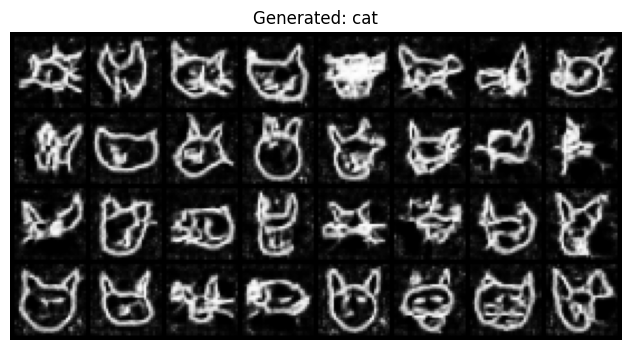

cat FID: 108.37604274323057


In [ ]:
def run_category(name, url_name, num_epochs=30):
    """Download a QuickDraw category, train a DCGAN on it, show samples and print its FID."""
    fname = f"{url_name}.npy"                                          # per-category file (not a shared temp name)
    !wget -q -O "{fname}" "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{url_name}.npy"
    arr = np.load(fname)                                               # (N, 784) uint8 sketches
    ld = make_loader(arr)                                              # same preprocessing as birthday cake
    g, gl, dl = train_dcgan(ld, num_epochs)                            # reuse the DCGAN training function
    # ---- show a grid of generated samples ----
    g.eval()
    with torch.no_grad():
        f = g(torch.randn(32, nz, 1, 1, device=device)).cpu()
    grid = vutils.make_grid(f, nrow=8, normalize=True)
    plt.figure(figsize=(8,4)); plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.axis("off"); plt.title(f"Generated: {name}"); plt.show()
    # ---- FID against 2000 real samples of this category ----
    re = ld.dataset.tensors[0][:2000].to(device)
    with torch.no_grad():
        fe = torch.cat([g(torch.randn(200, nz, 1, 1, device=device)) for _ in range(10)])
    print(f"{name} FID:", fid_score(re, fe))
    return g

_ = run_category("cat", "cat")

Epoch  1/30 | D 0.101 | G 3.358
Epoch  2/30 | D 1.203 | G 2.776
Epoch  3/30 | D 0.087 | G 3.884
Epoch  4/30 | D 0.166 | G 2.920
Epoch  5/30 | D 0.682 | G 1.424
Epoch  6/30 | D 0.120 | G 3.451
Epoch  7/30 | D 1.241 | G 4.860
Epoch  8/30 | D 0.154 | G 3.635
Epoch  9/30 | D 0.115 | G 3.555
Epoch 10/30 | D 0.056 | G 4.058
Epoch 11/30 | D 0.100 | G 3.494
Epoch 12/30 | D 0.325 | G 2.084
Epoch 13/30 | D 0.071 | G 3.919
Epoch 14/30 | D 0.455 | G 2.014
Epoch 15/30 | D 0.034 | G 4.584
Epoch 16/30 | D 0.427 | G 2.877
Epoch 17/30 | D 0.046 | G 4.456
Epoch 18/30 | D 0.022 | G 5.682
Epoch 19/30 | D 0.617 | G 1.692
Epoch 20/30 | D 0.031 | G 4.961
Epoch 21/30 | D 0.044 | G 5.789
Epoch 22/30 | D 0.052 | G 4.167
Epoch 23/30 | D 0.015 | G 5.720
Epoch 24/30 | D 0.022 | G 5.788
Epoch 25/30 | D 0.012 | G 6.281
Epoch 26/30 | D 0.647 | G 1.949
Epoch 27/30 | D 0.140 | G 3.375
Epoch 28/30 | D 0.026 | G 5.471
Epoch 29/30 | D 0.011 | G 6.364
Epoch 30/30 | D 0.391 | G 2.019


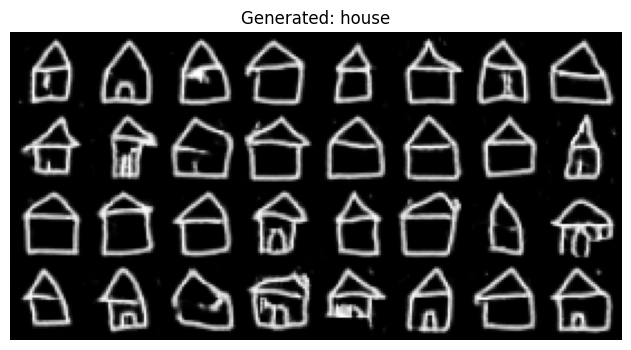

house FID: 33.17466329615784


In [ ]:
_ = run_category("house", "house")

### Extension discussion

As an extension, the same DCGAN architecture was trained on the Cat category to investigate how the model performs on a more complex dataset. Unlike birthday cakes, cat sketches have much greater variation in shape, facial features and drawing styles, making them more difficult for the generator to learn.

The model achieved a Cat FID score of 108.38, which is considerably higher than the Birthday Cake FID of 35.35. This higher FID indicates that the generated cat sketches were less similar to the real QuickDraw images. The result suggests that the DCGAN struggled to capture the greater diversity and complexity of the cat drawings, producing images with lower visual quality and less consistent features.

This comparison highlights that the complexity of the training data has a significant impact on GAN performance. Simpler categories with more consistent shapes are easier for the model to learn, whereas categories with large variations require more training data, longer training, or more advanced GAN architectures. Techniques such as WGAN-GP, StyleGAN, or additional hyperparameter tuning could improve image quality and help the generator learn more complex sketch distributions more effectively.